In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal as _lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

%cd {PROJECT_ROOT}

PROJECT_ROOT: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe
cwd: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
sys.path: ['/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe', '/home/victor/gw/Gravitational-Waves-Lab/cbc_pe']
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe


In [10]:
from src.io import load_dataset_npz

loaded = load_dataset_npz("data/debug/bbh_debug_500.npz")

In [12]:
X = loaded.X
y = loaded.y
metadata = loaded.metadata
parameters = loaded.parameters

print(loaded.X.shape)
print(loaded.y.shape)
print(len(loaded.parameters))
print(len(loaded.metadata))


(500, 3, 16384)
(500, 3)
500
500


In [13]:

snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])
initial_snrs = np.array([m["snr"]["initial_network_snr"] for m in metadata])
rescaled = np.array([m["snr"]["snr_rescaled"] for m in metadata])
truncated = np.array([m["windowing"]["is_truncated"] for m in metadata])

clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in metadata
])

margins = np.array([
    m["placement"].get("margins_respected", False)
    for m in metadata
])

m1 = np.array([p["mass_1"] for p in parameters])
m2 = np.array([p["mass_2"] for p in parameters])
distance = np.array([p["distance"] for p in parameters])
chirp = np.array([p["chirp_mass"] for p in parameters])
mtot = np.array([p["total_mass"] for p in parameters])
chieff = np.array([p["chi_eff"] for p in parameters])

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

print("\nSNR")
print("final min/mean/max:", snrs.min(), snrs.mean(), snrs.max())
print("initial min/mean/max:", initial_snrs.min(), initial_snrs.mean(), initial_snrs.max())
print("rescaled:", rescaled.sum(), "/", len(rescaled))

print("\nWindow / injection")
print("truncated:", truncated.sum(), "/", len(truncated))
print("clipped:", clipped.sum(), "/", len(clipped))
print("margins respected:", margins.sum(), "/", len(margins))

print("\nParameters")
print("m1 min/mean/max:", m1.min(), m1.mean(), m1.max())
print("m2 min/mean/max:", m2.min(), m2.mean(), m2.max())
print("distance min/mean/max:", distance.min(), distance.mean(), distance.max())
print("chirp min/mean/max:", chirp.min(), chirp.mean(), chirp.max())
print("mtot min/mean/max:", mtot.min(), mtot.mean(), mtot.max())
print("chieff min/mean/max:", chieff.min(), chieff.mean(), chieff.max())

X: (500, 3, 16384) float32
y: (500, 3) float32

SNR
final min/mean/max: 10.001957408666202 17.023770121859865 24.966446988722883
initial min/mean/max: 0.7250832672631297 18.131829763548602 199.57931998247113
rescaled: 361 / 500

Window / injection
truncated: 1 / 500
clipped: 0 / 500
margins respected: 348 / 500

Parameters
m1 min/mean/max: 7.20451581072826 62.17036928199559 89.89545052262226
m2 min/mean/max: 5.2667242207066165 34.58260660776308 86.5239621846583
distance min/mean/max: 91.98694210158102 1741.2421011278298 6481.187387074528
chirp min/mean/max: 5.371450798728568 38.47296350907447 76.15490490134094
mtot min/mean/max: 12.51344359892025 96.75297588975867 174.97070613483592
chieff min/mean/max: -0.9372033211301566 0.00967917759453334 0.9781015493195233


In [14]:
low, high = 10.0, 25.0
tol = loaded.metadata[0]["simulation"]["snr_relative_tolerance"]

assert np.all(snrs >= low * (1 - tol))
assert np.all(snrs <= high * (1 + tol))
assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)
assert np.all((-1 <= chieff) & (chieff <= 1))
assert not np.any(clipped)
assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("Loaded 500 dataset checks OK")

Loaded 500 dataset checks OK


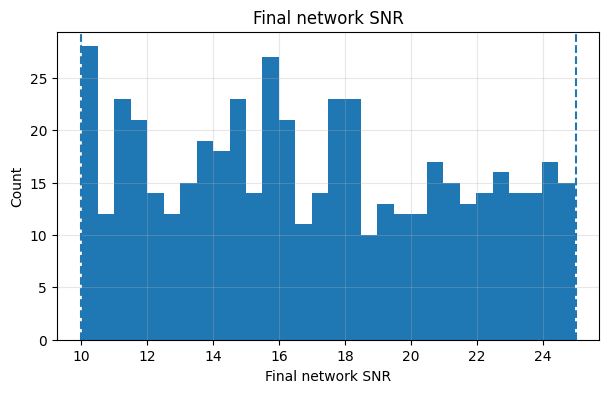

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(snrs, bins=30)
plt.axvline(10, linestyle="--")
plt.axvline(25, linestyle="--")
plt.xlabel("Final network SNR")
plt.ylabel("Count")
plt.title("Final network SNR")
plt.grid(alpha=0.3)
plt.show()

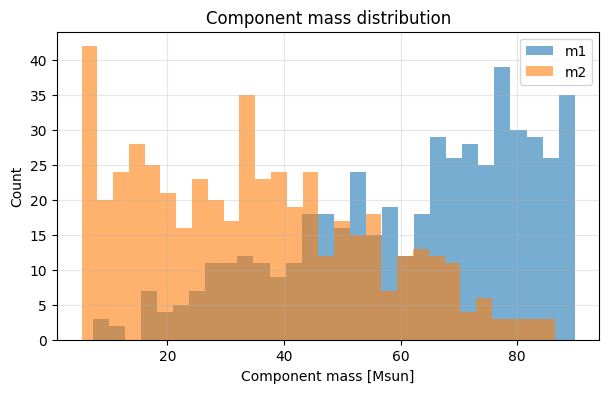

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(m1, bins=30, alpha=0.6, label="m1")
plt.hist(m2, bins=30, alpha=0.6, label="m2")
plt.xlabel("Component mass [Msun]")
plt.ylabel("Count")
plt.title("Component mass distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

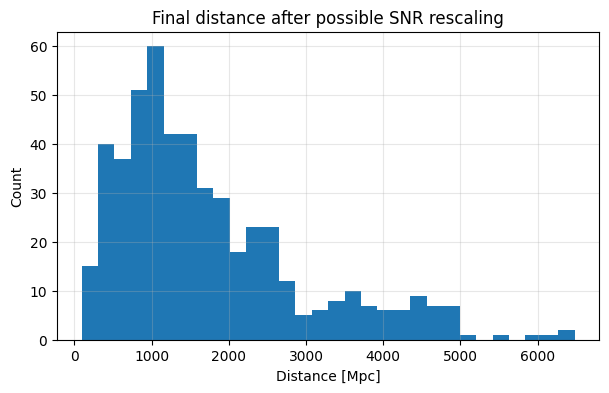

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(distance, bins=30)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Count")
plt.title("Final distance after possible SNR rescaling")
plt.grid(alpha=0.3)
plt.show()

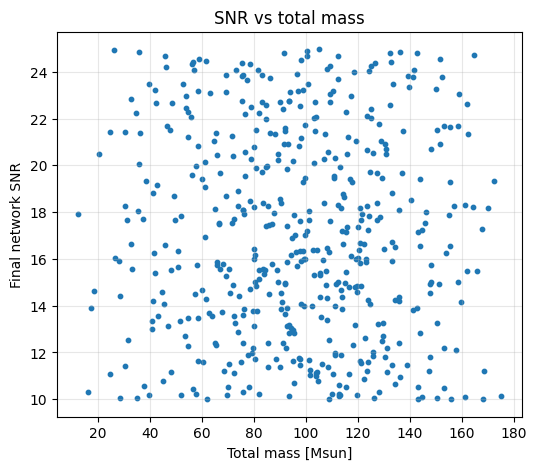

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(mtot, snrs, s=10)
plt.xlabel("Total mass [Msun]")
plt.ylabel("Final network SNR")
plt.title("SNR vs total mass")
plt.grid(alpha=0.3)
plt.show()

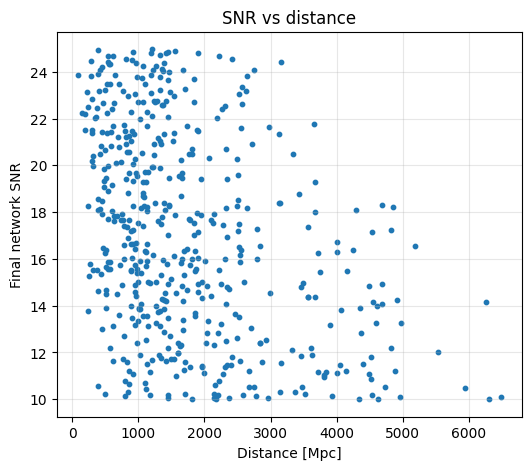

In [19]:
plt.figure(figsize=(6, 5))
plt.scatter(distance, snrs, s=10)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Final network SNR")
plt.title("SNR vs distance")
plt.grid(alpha=0.3)
plt.show()

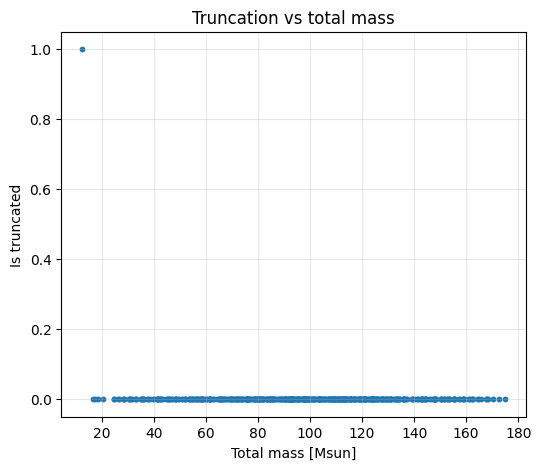

In [20]:
plt.figure(figsize=(6, 5))
plt.scatter(mtot, truncated.astype(int), s=10)
plt.xlabel("Total mass [Msun]")
plt.ylabel("Is truncated")
plt.title("Truncation vs total mass")
plt.grid(alpha=0.3)
plt.show()

In [21]:
def plot_loaded_sample(loaded, i, config_length=None):
    X = loaded.X[i]
    meta = loaded.metadata[i]
    params = loaded.parameters[i]

    fs = meta["simulation"]["sampling_frequency"]
    dt = 1.0 / fs
    t = np.arange(X.shape[1]) * dt

    detectors = meta["detectors"]

    fig, axes = plt.subplots(len(detectors), 1, figsize=(12, 6), sharex=True)
    if len(detectors) == 1:
        axes = [axes]

    for j, det in enumerate(detectors):
        axes[j].plot(t, X[j])
        axes[j].set_ylabel(det)
        axes[j].grid(alpha=0.3)

    axes[-1].set_xlabel("Time from segment start [s]")

    fig.suptitle(
        f"Sample {i} | SNR={meta['snr']['final_network_snr']:.2f} | "
        f"m1={params['mass_1']:.1f}, m2={params['mass_2']:.1f}, "
        f"truncated={meta['windowing']['is_truncated']}"
    )

    plt.tight_layout()
    plt.show()

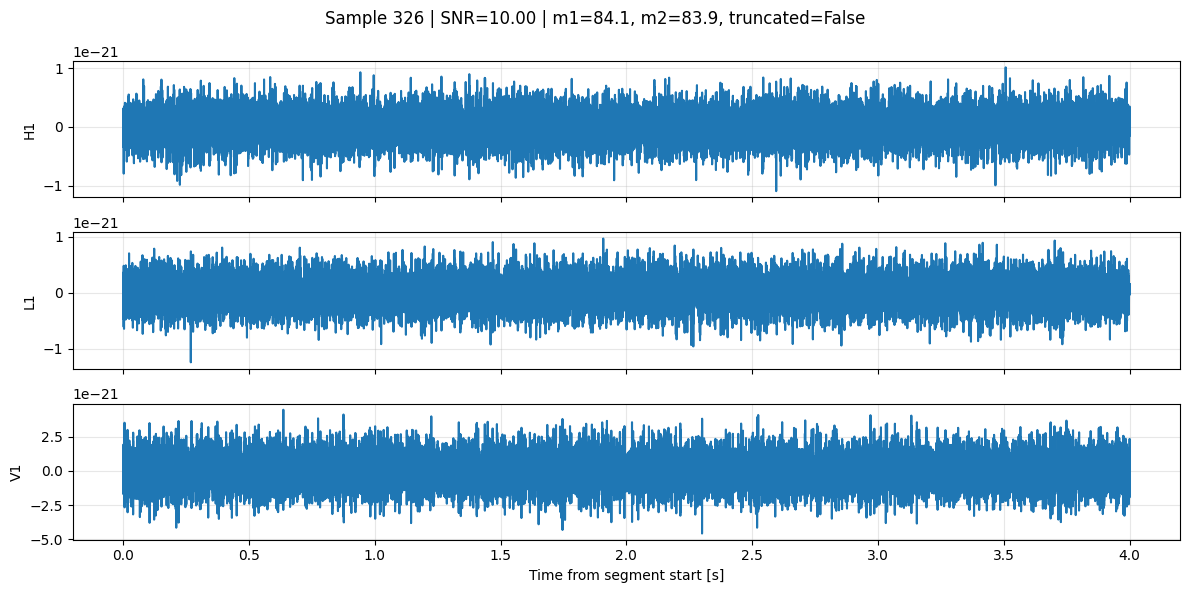

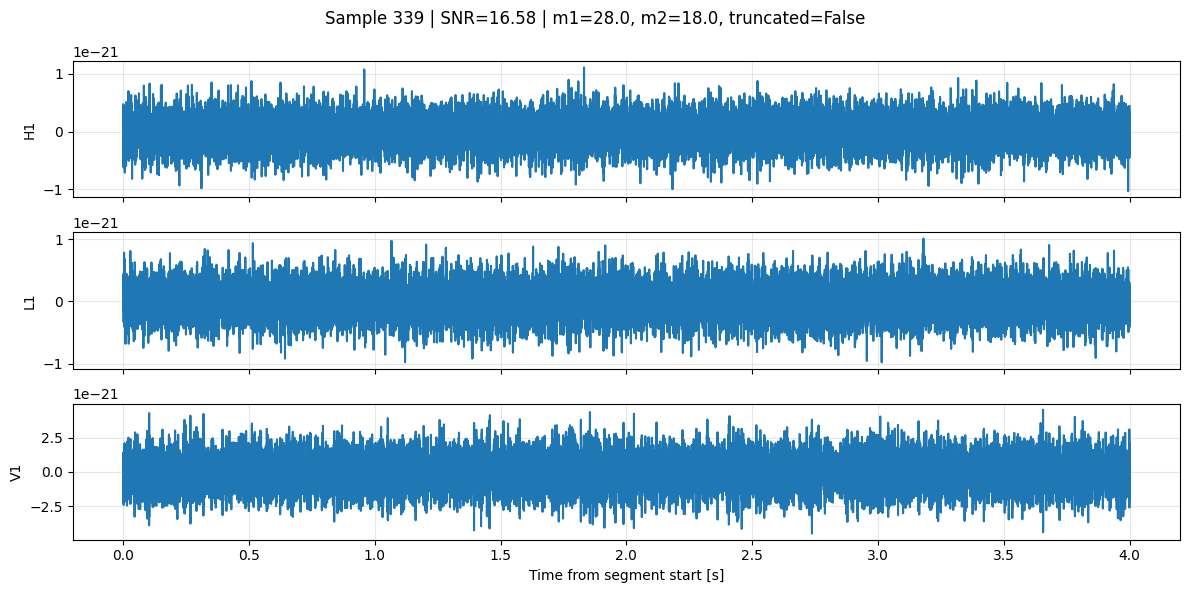

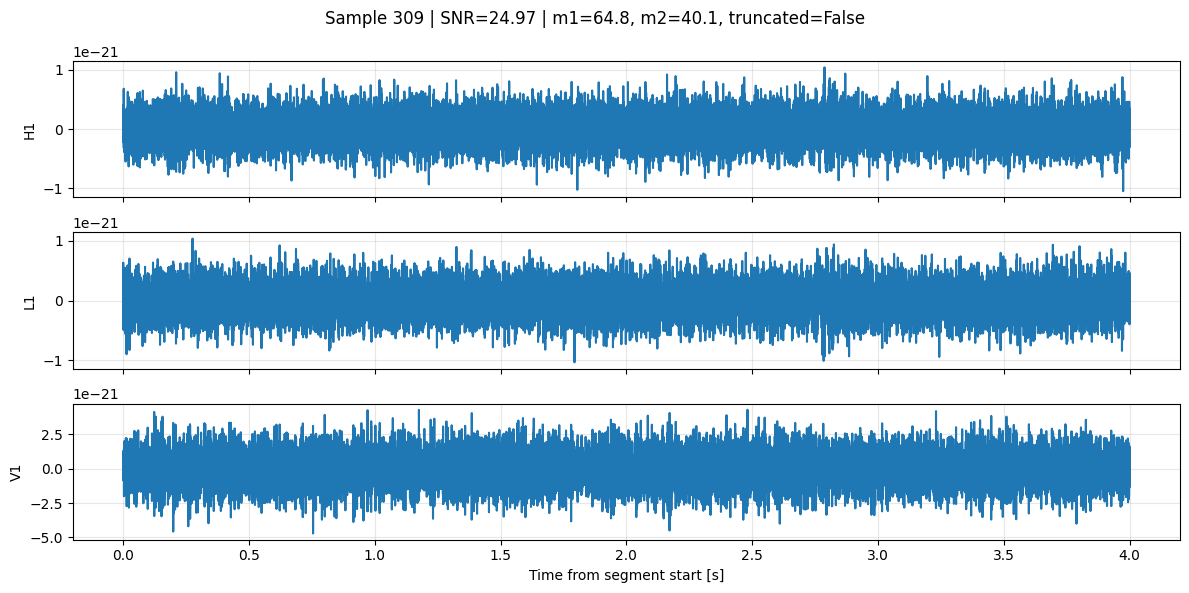

In [22]:
idx_sorted_snr = np.argsort(snrs)

for i in [idx_sorted_snr[0], idx_sorted_snr[len(idx_sorted_snr)//2], idx_sorted_snr[-1]]:
    plot_loaded_sample(loaded, i)

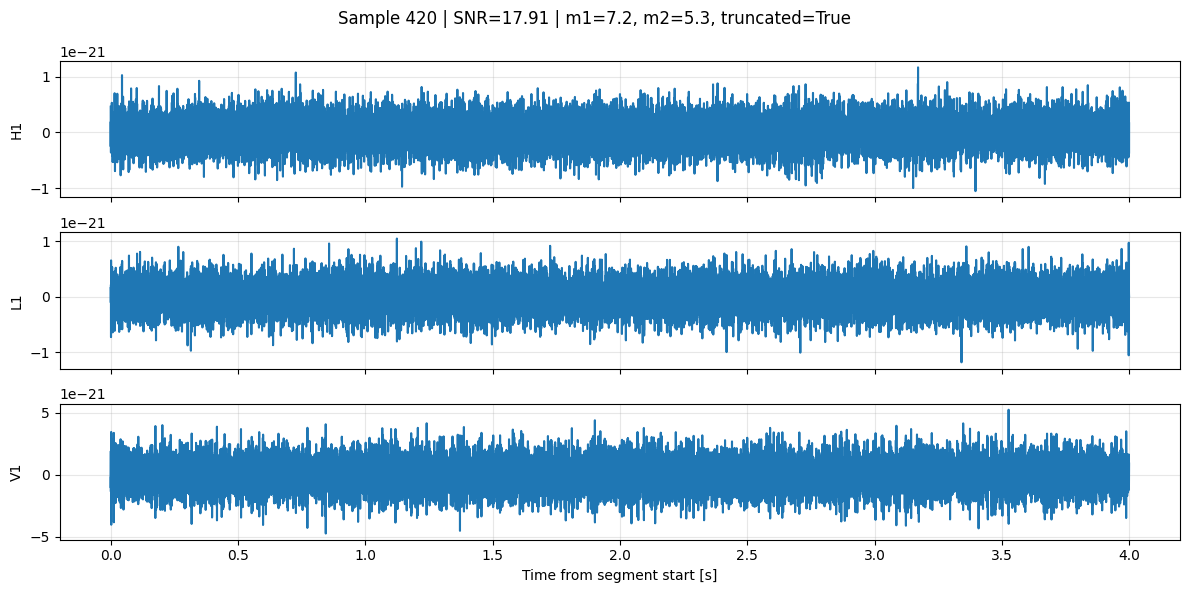

In [23]:
truncated_indices = np.where(truncated)[0]

for i in truncated_indices[:3]:
    plot_loaded_sample(loaded, i)

### 3500 debugging

In [24]:
from src.io import load_dataset_npz
import numpy as np

loaded = load_dataset_npz("data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n3500.npz")

X = loaded.X
y = loaded.y
parameters = loaded.parameters
metadata = loaded.metadata

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("parameters:", len(parameters))
print("metadata:", len(metadata))

X: (3500, 3, 16384) float32
y: (3500, 3) float32
parameters: 3500
metadata: 3500


In [25]:
assert X.shape == (3500, 3, 16384)
assert y.shape == (3500, 3)
assert len(parameters) == 3500
assert len(metadata) == 3500
assert np.all(np.isfinite(X))
assert np.all(np.isfinite(y))

print("Basic loaded checks OK")

Basic loaded checks OK


In [26]:
snrs = np.array([m["snr"]["final_network_snr"] for m in metadata])
initial_snrs = np.array([m["snr"]["initial_network_snr"] for m in metadata])
rescaled = np.array([m["snr"]["snr_rescaled"] for m in metadata])
truncated = np.array([m["windowing"]["is_truncated"] for m in metadata])

clipped = np.array([
    any(m["injection"][det]["is_partially_clipped"] for det in m["detectors"])
    for m in metadata
])

margins = np.array([
    m["placement"].get("margins_respected", False)
    for m in metadata
])

m1 = np.array([p["mass_1"] for p in parameters])
m2 = np.array([p["mass_2"] for p in parameters])
distance = np.array([p["distance"] for p in parameters])
chirp = np.array([p["chirp_mass"] for p in parameters])
mtot = np.array([p["total_mass"] for p in parameters])
chieff = np.array([p["chi_eff"] for p in parameters])

print("SNR final min/mean/max:", snrs.min(), snrs.mean(), snrs.max())
print("SNR initial min/mean/max:", initial_snrs.min(), initial_snrs.mean(), initial_snrs.max())
print("Rescaled:", rescaled.sum(), "/", len(rescaled))
print("Truncated:", truncated.sum(), "/", len(truncated))
print("Clipped:", clipped.sum(), "/", len(clipped))
print("Margins respected:", margins.sum(), "/", len(margins))

print("m1 min/mean/max:", m1.min(), m1.mean(), m1.max())
print("m2 min/mean/max:", m2.min(), m2.mean(), m2.max())
print("distance min/mean/max:", distance.min(), distance.mean(), distance.max())
print("chirp min/mean/max:", chirp.min(), chirp.mean(), chirp.max())
print("mtot min/mean/max:", mtot.min(), mtot.mean(), mtot.max())
print("chi_eff min/mean/max:", chieff.min(), chieff.mean(), chieff.max())

SNR final min/mean/max: 10.002648662467065 16.921214125999292 24.98982630662876
SNR initial min/mean/max: 0.567144666538648 18.325128606590713 451.65283930116465
Rescaled: 2472 / 3500
Truncated: 3 / 3500
Clipped: 0 / 3500
Margins respected: 2452 / 3500
m1 min/mean/max: 5.090867149393484 61.96477026612855 89.99974875040378
m2 min/mean/max: 5.010646374888234 33.326320890606596 87.35764992191412
distance min/mean/max: 102.82232548326726 1687.5867028487623 8368.876994460888
chirp min/mean/max: 4.42567812924173 37.49636515426655 76.58092521275596
mtot min/mean/max: 10.167550245937578 95.29109115673515 175.94189648715118
chi_eff min/mean/max: -0.9897989843134043 -0.0047347668182515365 0.9832553522843216


In [27]:
tol = metadata[0]["simulation"]["snr_relative_tolerance"]
low, high = metadata[0]["simulation"]["target_network_snr_range"]

assert np.all(snrs >= low * (1 - tol))
assert np.all(snrs <= high * (1 + tol))
assert not np.any(clipped)
assert np.all(m1 >= m2)
assert np.all(m2 >= 5.0)
assert np.all((-1.0 <= chieff) & (chieff <= 1.0))

print("Physics/SNR loaded checks OK")

Physics/SNR loaded checks OK


train: 2000
val:    500
cal:    500
test:   500

In [28]:
from pathlib import Path
import numpy as np

N = X.shape[0]
assert N == 3500

split_rng = np.random.default_rng(2026)
indices = split_rng.permutation(N)

n_train = 2000
n_val = 500
n_cal = 500
n_test = 500

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
cal_idx = indices[n_train + n_val:n_train + n_val + n_cal]
test_idx = indices[n_train + n_val + n_cal:]

assert len(train_idx) == n_train
assert len(val_idx) == n_val
assert len(cal_idx) == n_cal
assert len(test_idx) == n_test

split_path = Path("data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n3500_splits.npz")

np.savez(
    split_path,
    train_idx=train_idx,
    val_idx=val_idx,
    cal_idx=cal_idx,
    test_idx=test_idx,
)

print("Saved splits to:", split_path)

Saved splits to: data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n3500_splits.npz


In [29]:
y_train = y[train_idx]

label_mean = y_train.mean(axis=0)
label_std = y_train.std(axis=0)

print("label_mean:", label_mean)
print("label_std:", label_std)

assert np.all(label_std > 0)

stats_path = Path("data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n3500_label_stats.npz")

np.savez(
    stats_path,
    label_mean=label_mean,
    label_std=label_std,
    label_names=np.array(["chirp_mass", "total_mass", "chi_eff"]),
)

print("Saved label stats to:", stats_path)

label_mean: [ 3.7451038e+01  9.5063110e+01 -1.1073472e-02]
label_std: [16.265327  34.142334   0.4306438]
Saved label stats to: data/raw/bbh_raw_4s_seobnrv4opt_snr10-25_n3500_label_stats.npz


In [30]:
y_train_std = (y[train_idx] - label_mean) / label_std
y_val_std = (y[val_idx] - label_mean) / label_std
y_cal_std = (y[cal_idx] - label_mean) / label_std
y_test_std = (y[test_idx] - label_mean) / label_std

print(y_train_std.mean(axis=0))
print(y_train_std.std(axis=0))

[2.3762882e-06 2.3892521e-06 1.2114644e-08]
[0.99999905 0.99999964 0.99999905]
